<a href="https://colab.research.google.com/github/QARosa/EpiScope---Disease-Data-Analyzer/blob/GA-Branch/TCFase02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title 1. Configuração e Geração de Dados (Simulação do Dataset)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Configuração de Estilo
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

def generate_synthetic_data(n_samples=2000):
    """Gera dados sintéticos imitando Dengue, Zika e Chikungunya"""
    # Features baseadas no seu projeto
    features = ["febre", "mialgia", "cefaleia", "exantema", "vomito", "nausea",
                "dor_costas", "conjuntvit", "artrite", "artralgia", "petequia_n",
                "leucopenia", "dor_retro", "idade", "sexo_encoded"]

    data = []
    labels = []
    classes = ["Dengue", "Zika", "Chikungunya"]

    for _ in range(n_samples):
        disease = random.choice(classes)
        row = {}

        # Probabilidades baseadas em sintomas clínicos reais (simplificado)
        if disease == "Dengue":
            row = {
                "febre": np.random.choice([0, 1], p=[0.1, 0.9]),
                "mialgia": np.random.choice([0, 1], p=[0.2, 0.8]),
                "dor_retro": np.random.choice([0, 1], p=[0.3, 0.7]),
                "artralgia": np.random.choice([0, 1], p=[0.6, 0.4]),
                "exantema": np.random.choice([0, 1], p=[0.7, 0.3]),
            }
        elif disease == "Chikungunya":
            row = {
                "febre": np.random.choice([0, 1], p=[0.1, 0.9]),
                "artralgia": np.random.choice([0, 1], p=[0.05, 0.95]), # Muito forte
                "artrite": np.random.choice([0, 1], p=[0.2, 0.8]),
                "dor_costas": np.random.choice([0, 1], p=[0.4, 0.6]),
            }
        else: # Zika
            row = {
                "febre": np.random.choice([0, 1], p=[0.6, 0.4]), # Febre baixa/ausente
                "exantema": np.random.choice([0, 1], p=[0.1, 0.9]), # Muito forte
                "conjuntvit": np.random.choice([0, 1], p=[0.3, 0.7]),
                "mialgia": np.random.choice([0, 1], p=[0.5, 0.5]),
            }

        # Preenche o resto aleatoriamente com baixa probabilidade
        for f in features:
            if f not in row:
                row[f] = np.random.choice([0, 1], p=[0.85, 0.15])

        row['idade'] = random.randint(5, 80)
        row['sexo_encoded'] = random.choice([0, 1])

        data.append(list(row.values()))
        labels.append(classes.index(disease))

    X = pd.DataFrame(data, columns=features)
    y = pd.Series(labels)
    return X, y, classes

print("🎲 Gerando Dataset Sintético para Experimentos...")
X, y, class_names = generate_synthetic_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"✅ Dados prontos: {len(X)} amostras.")


🎲 Gerando Dataset Sintético para Experimentos...
✅ Dados prontos: 2000 amostras.


In [2]:
# @title 2. Implementação do Algoritmo Genético (Engine)
class GeneticOptimizer:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

    def get_random_gene(self, param_name):
        """DNA do Modelo: Define o espaço de busca dos hiperparâmetros"""
        ranges = {
            "n_estimators": lambda: random.randint(50, 400),
            "max_depth": lambda: random.randint(3, 15),
            "learning_rate": lambda: round(random.uniform(0.01, 0.3), 3),
            "subsample": lambda: round(random.uniform(0.6, 1.0), 2),
            "colsample_bytree": lambda: round(random.uniform(0.6, 1.0), 2),
            "gamma": lambda: round(random.uniform(0, 2), 2),
        }
        return ranges.get(param_name, lambda: 0)()

    def create_individual(self):
        """Cria um 'cromossomo' (conjunto de hiperparâmetros)"""
        return {
            "n_estimators": self.get_random_gene("n_estimators"),
            "max_depth": self.get_random_gene("max_depth"),
            "learning_rate": self.get_random_gene("learning_rate"),
            "subsample": self.get_random_gene("subsample"),
            "colsample_bytree": self.get_random_gene("colsample_bytree"),
            "gamma": self.get_random_gene("gamma"),
        }

    def evaluate(self, params):
        """Função de Fitness: Treina e retorna a Acurácia"""
        try:
            model = XGBClassifier(
                **params,
                objective="multi:softmax",
                num_class=3,
                n_jobs=-1,
                random_state=42,
                verbosity=0
            )
            model.fit(self.X_train, self.y_train)
            preds = model.predict(self.X_test)
            return accuracy_score(self.y_test, preds)
        except:
            return 0.0

    def run(self, generations=8, population_size=10):
        """Loop Evolutivo"""
        population = [self.create_individual() for _ in range(population_size)]
        history = []
        best_overall = {"accuracy": 0, "params": {}}

        print(f"🧬 Iniciando Evolução (População: {population_size}, Gerações: {generations})")

        for gen in range(generations):
            # 1. Avaliação
            scores = []
            for indiv in population:
                acc = self.evaluate(indiv)
                scores.append((acc, indiv))
                if acc > best_overall["accuracy"]:
                    best_overall = {"accuracy": acc, "params": indiv}

            scores.sort(key=lambda x: x[0], reverse=True)
            best_gen_acc = scores[0][0]
            avg_gen_acc = np.mean([s[0] for s in scores])

            history.append({
                "generation": gen + 1,
                "best_accuracy": best_gen_acc,
                "avg_accuracy": avg_gen_acc,
                "best_params": scores[0][1] # Guarda params do melhor da geração
            })

            print(f"  -> Geração {gen+1}: Melhor Acc = {best_gen_acc:.4f} | Média = {avg_gen_acc:.4f}")

            # 2. Seleção (Elitismo: Top 50%)
            top_half = [s[1] for s in scores[: population_size // 2]]

            # 3. Crossover e Mutação
            new_population = top_half[:]
            while len(new_population) < population_size:
                parent1 = random.choice(top_half)
                parent2 = random.choice(top_half)
                child = parent1.copy()

                # Crossover (50% chance por gene)
                for k in child.keys():
                    if random.random() > 0.5:
                        child[k] = parent2[k]

                # Mutação (20% chance)
                if random.random() < 0.2:
                    gene = random.choice(list(child.keys()))
                    child[gene] = self.get_random_gene(gene)

                new_population.append(child)

            population = new_population

        return history, best_overall

print("✅ Classe GeneticOptimizer carregada.")


✅ Classe GeneticOptimizer carregada.


🧬 Iniciando Evolução (População: 12, Gerações: 10)
  -> Geração 1: Melhor Acc = 0.5750 | Média = 0.5586
  -> Geração 2: Melhor Acc = 0.5783 | Média = 0.5717
  -> Geração 3: Melhor Acc = 0.5783 | Média = 0.5749
  -> Geração 4: Melhor Acc = 0.5817 | Média = 0.5763
  -> Geração 5: Melhor Acc = 0.5817 | Média = 0.5753
  -> Geração 6: Melhor Acc = 0.5817 | Média = 0.5786
  -> Geração 7: Melhor Acc = 0.5817 | Média = 0.5789
  -> Geração 8: Melhor Acc = 0.5817 | Média = 0.5786
  -> Geração 9: Melhor Acc = 0.5817 | Média = 0.5797
  -> Geração 10: Melhor Acc = 0.5817 | Média = 0.5817


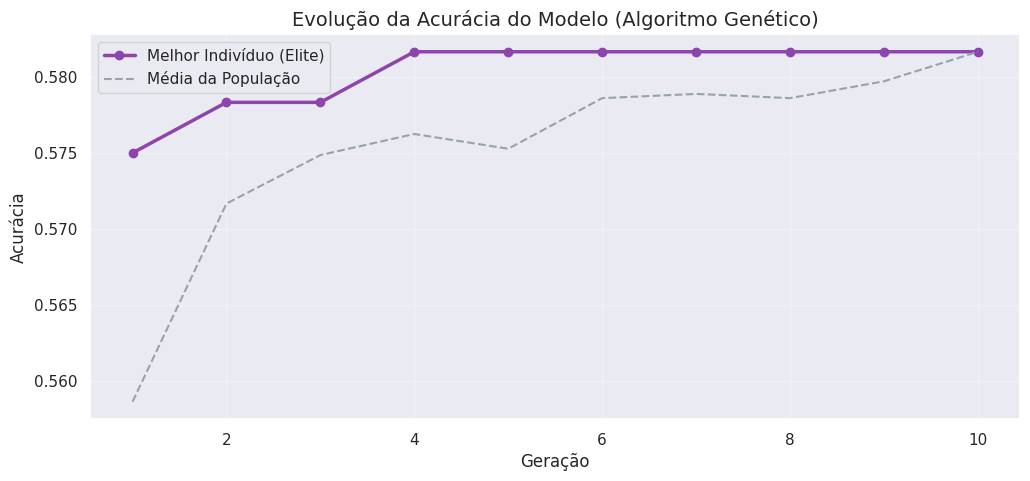

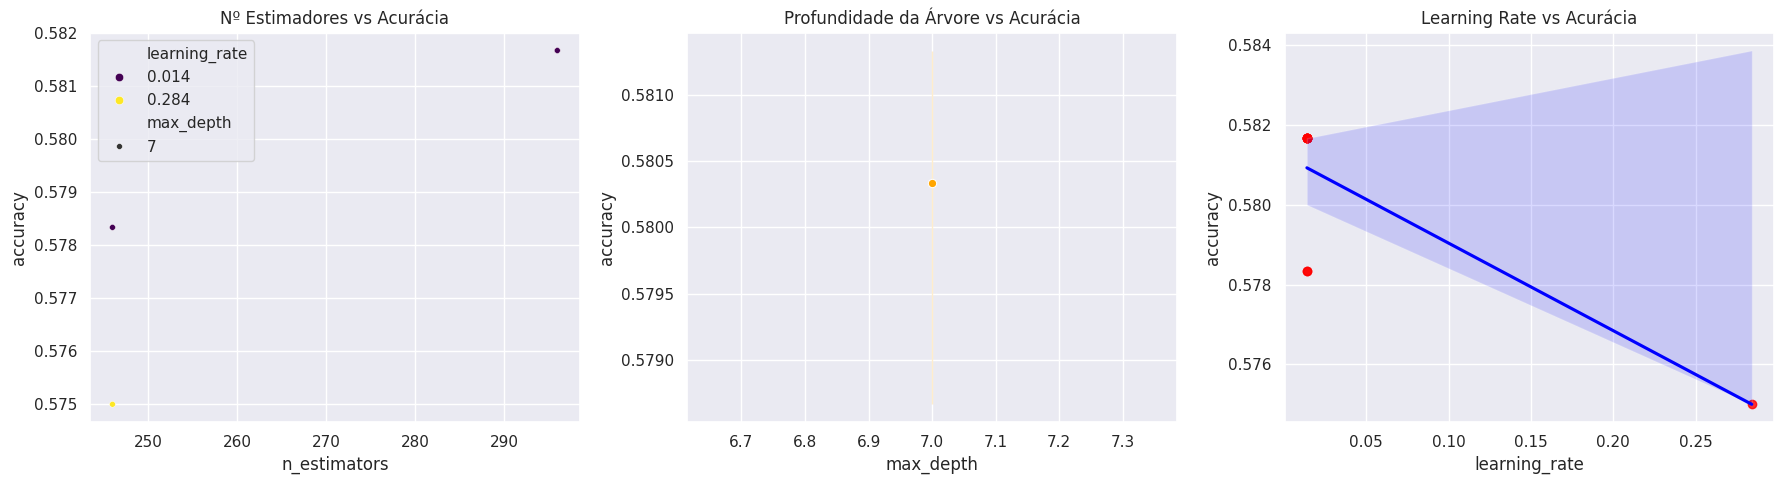


🏆 MELHOR CONFIGURAÇÃO ENCONTRADA:
Acurácia: 58.17%
Parâmetros: {'n_estimators': 296, 'max_depth': 7, 'learning_rate': 0.014, 'subsample': 0.71, 'colsample_bytree': 0.74, 'gamma': 1.63}


In [3]:
# @title 3. Execução do Experimento e Gráficos de Defesa
# Rodar o AG
optimizer = GeneticOptimizer(X_train, y_train, X_test, y_test)
history, best_result = optimizer.run(generations=10, population_size=12)

# --- GRÁFICO 1: Curva de Convergência Evolutiva ---
generations = [h['generation'] for h in history]
best_accs = [h['best_accuracy'] for h in history]
avg_accs = [h['avg_accuracy'] for h in history]

plt.figure(figsize=(12, 5))
plt.plot(generations, best_accs, marker='o', label='Melhor Indivíduo (Elite)', color='#8e44ad', linewidth=2.5)
plt.plot(generations, avg_accs, linestyle='--', label='Média da População', color='#95a5a6')
plt.title("Evolução da Acurácia do Modelo (Algoritmo Genético)", fontsize=14)
plt.xlabel("Geração")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- GRÁFICO 2: Impacto dos Hiperparâmetros (Parallel Coordinates simplificado) ---
# Vamos pegar os parâmetros do melhor modelo de cada geração para ver a tendência
params_history = pd.DataFrame([h['best_params'] for h in history])
params_history['accuracy'] = best_accs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=params_history, x='n_estimators', y='accuracy', size='max_depth', hue='learning_rate', ax=axes[0], palette='viridis')
axes[0].set_title("Nº Estimadores vs Acurácia")

sns.lineplot(data=params_history, x='max_depth', y='accuracy', marker='o', color='orange', ax=axes[1])
axes[1].set_title("Profundidade da Árvore vs Acurácia")

sns.regplot(data=params_history, x='learning_rate', y='accuracy', ax=axes[2], scatter_kws={'color': 'red'}, line_kws={'color': 'blue'})
axes[2].set_title("Learning Rate vs Acurácia")

plt.tight_layout()
plt.show()

# --- RESULTADO FINAL ---
print("\n" + "="*40)
print(f"🏆 MELHOR CONFIGURAÇÃO ENCONTRADA:")
print(f"Acurácia: {best_result['accuracy']:.2%}")
print(f"Parâmetros: {best_result['params']}")
print("="*40)
